In [1]:
# Data handling libraries
import pandas as pd                 # For dataframes and data manipulation
import numpy as np                  # For numerical operations and arrays

# Visualization libraries
import matplotlib.pyplot as plt     # For plotting charts and graphs
import matplotlib.dates as mdates   # For formatting date axis in plots
import seaborn as sns               # For attractive statistical visualizations

# Utility libraries
import warnings, os, joblib         # warnings=hide warnings, os=file paths, joblib=model saving/loading
from datetime import datetime, timedelta   # For date and time operations

# ── Machine Learning Models ──
import xgboost as xgb               # XGBoost Regressor
import lightgbm as lgb             # LightGBM Regressor
from catboost import CatBoostRegressor   # CatBoost Regressor

# ── Evaluation Metrics ──
from sklearn.metrics import (
    mean_absolute_error,           # MAE
    mean_squared_error,           # MSE / RMSE
    r2_score                      # R² Score
)

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Ignore warning messages
warnings.filterwarnings('ignore')

# Display settings for pandas
pd.set_option('display.max_columns', 50)

# Set seaborn chart theme
sns.set_theme(style='darkgrid', palette='muted')

# Set image quality for plots
plt.rcParams['figure.dpi'] = 120

# Target regions / electricity zones
REGIONS = ['DELHI', 'BRPL', 'BYPL', 'NDPL', 'NDMC', 'MES']

# Random seed for reproducibility
RANDOM_STATE = 42

# Confirmation message
print('✅ Imports done')

✅ Imports done


In [3]:
# List of public / festival holidays in Delhi used as feature for demand prediction
DELHI_HOLIDAYS = [

    # ── Holidays for Year 2022 ──
    '2022-01-26','2022-03-01','2022-03-18','2022-04-10','2022-04-14',
    '2022-04-15','2022-05-03','2022-05-16','2022-07-10','2022-08-09',
    '2022-08-15','2022-08-19','2022-10-02','2022-10-05','2022-10-09',
    '2022-10-24','2022-10-25','2022-10-26','2022-11-08','2022-12-25',

    # ── Holidays for Year 2023 ──
    '2023-01-26','2023-02-18','2023-03-08','2023-03-30','2023-04-07',
    '2023-04-14','2023-04-21','2023-04-22','2023-05-05','2023-06-29',
    '2023-07-29','2023-08-15','2023-09-06','2023-09-07','2023-09-19',
    '2023-10-02','2023-10-24','2023-11-13','2023-11-14','2023-11-15',
    '2023-11-27','2023-12-25',

    # ── Holidays for Year 2024 ──
    '2024-01-22','2024-01-26','2024-03-08','2024-03-25','2024-03-29',
    '2024-04-09','2024-04-11','2024-04-14','2024-04-17','2024-05-23',
    '2024-06-17','2024-07-17','2024-08-15','2024-08-26','2024-09-16',
    '2024-10-02','2024-10-12','2024-10-13','2024-11-01','2024-11-02',
    '2024-11-03','2024-11-15','2024-12-25',

    # ── Holidays for Year 2025 ──
    '2025-01-26','2025-02-26','2025-03-14','2025-03-31','2025-04-06',
    '2025-04-10','2025-04-14','2025-05-12','2025-06-07','2025-07-06',
    '2025-08-15','2025-08-16','2025-09-05','2025-10-02','2025-10-20',
    '2025-10-21','2025-11-05','2025-12-25',

    # ── Holidays for Year 2026 ──
    '2026-01-26','2026-02-15','2026-03-20','2026-03-22','2026-03-27',
    '2026-03-29','2026-04-14'
]

# Convert list into set for faster lookup while feature engineering
HOLIDAY_SET = set(DELHI_HOLIDAYS)

# Print total unique holidays loaded
print(f'✅ Loaded {len(HOLIDAY_SET)} unique holiday dates')

# ── Holiday count summary year-wise ──
by_year = {}

# Count holidays in each year
for d in HOLIDAY_SET:
    yr = d[:4]                         # Extract year from date string
    by_year[yr] = by_year.get(yr, 0) + 1

# Display yearly holiday counts
for yr in sorted(by_year):
    print(f'  {yr}: {by_year[yr]} holidays')

✅ Loaded 90 unique holiday dates
  2022: 20 holidays
  2023: 22 holidays
  2024: 23 holidays
  2025: 18 holidays
  2026: 7 holidays


In [5]:
# ── IMPORTANT: Update file paths if dataset location changes ──

# Path of electricity demand dataset (5-minute interval data)
SLDC_PATH = 'delhi_sldc_5min_2022_2026.csv'

# Path of weather dataset (5-minute interpolated weather data)
WEATHER_PATH = 'Delhi_Weather_5M.csv'

# Read CSV files into DataFrames
sldc = pd.read_csv(SLDC_PATH)   # Electricity load / demand data
wx   = pd.read_csv(WEATHER_PATH) # Weather data

# ── Convert Date + TimeSlot into proper datetime format ──

# For electricity dataset
sldc['datetime'] = pd.to_datetime(
    sldc['Date'] + ' ' + sldc['TimeSlot'],
    dayfirst=True
)

# For weather dataset
wx['datetime'] = pd.to_datetime(
    wx['Date'] + ' ' + wx['TimeSlot'],
    dayfirst=True
)

# ── Sort data chronologically ──
sldc.sort_values('datetime', inplace=True)
wx.sort_values('datetime', inplace=True)

# Reset index after sorting
sldc.reset_index(drop=True, inplace=True)
wx.reset_index(drop=True, inplace=True)

# ── Print dataset overview ──

# Shape + date range of electricity dataset
print(
    f'SLDC  : {sldc.shape} | '
    f'{sldc["datetime"].min()} → {sldc["datetime"].max()}'
)

# Shape + date range of weather dataset
print(
    f'Weather: {wx.shape} | '
    f'{wx["datetime"].min()} → {wx["datetime"].max()}'
)

# Print available columns
print('\nSLDC columns:', list(sldc.columns))
print('Weather columns:', list(wx.columns))

SLDC  : (430782, 9) | 2022-01-01 00:00:00 → 2026-04-01 23:55:00
Weather: (446965, 12) | 2022-01-01 00:00:00 → 2026-04-01 23:00:00

SLDC columns: ['Date', 'TimeSlot', 'DELHI', 'BRPL', 'BYPL', 'NDPL', 'NDMC', 'MES', 'datetime']
Weather columns: ['Date', 'TimeSlot', 'Temperature (°C)', 'Relative Humidity (%)', 'Apparent Temperature (°C)', 'Precipitation (mm)', 'Wind Speed (m/s)', 'Cloud Cover Total (%)', 'Cloud Cover Low (%)', 'Cloud Cover Mid (%)', 'Cloud Cover High (%)', 'datetime']


In [7]:
# ── Descriptive statistics for electricity demand data ──
print('=== SLDC Demand Stats (MW) ===')

# Show count, mean, std, min, max, quartiles for all regions
print(
    sldc[REGIONS]
    .describe()
    .round(2)
)

# ── Check missing/null values ──
print('\n=== Missing Values ===')

# Missing values in electricity demand columns
print(
    sldc[REGIONS]
    .isnull()
    .sum()
)

# Missing values in selected weather feature columns
print(
    wx[
        [
            'Temperature (°C)',
            'Relative Humidity (%)',
            'Apparent Temperature (°C)',
            'Precipitation (mm)',
            'Wind Speed (m/s)',
            'Cloud Cover Total (%)'
        ]
    ]
    .isnull()
    .sum()
)

=== SLDC Demand Stats (MW) ===
           DELHI       BRPL       BYPL       NDPL       NDMC        MES
count  430782.00  430782.00  430782.00  430782.00  430782.00  430782.00
mean     4121.60    1754.60     882.36    1240.02     176.76      27.93
std      1313.69     587.57     323.57     414.56      63.42       8.54
min      1302.08     470.73     229.03 -124343.88       2.67       0.00
25%      3237.82    1349.61     676.79    1001.99     130.61      21.53
50%      4021.70    1695.80     857.73    1238.57     165.16      27.25
75%      5061.94    2166.56    1109.52    1501.52     207.23      33.50
max      8631.53   64333.16   63516.52    2680.85     440.95      61.44

=== Missing Values ===
DELHI    0
BRPL     0
BYPL     0
NDPL     0
NDMC     0
MES      0
dtype: int64
Temperature (°C)             0
Relative Humidity (%)        0
Apparent Temperature (°C)    0
Precipitation (mm)           0
Wind Speed (m/s)             0
Cloud Cover Total (%)        0
dtype: int64


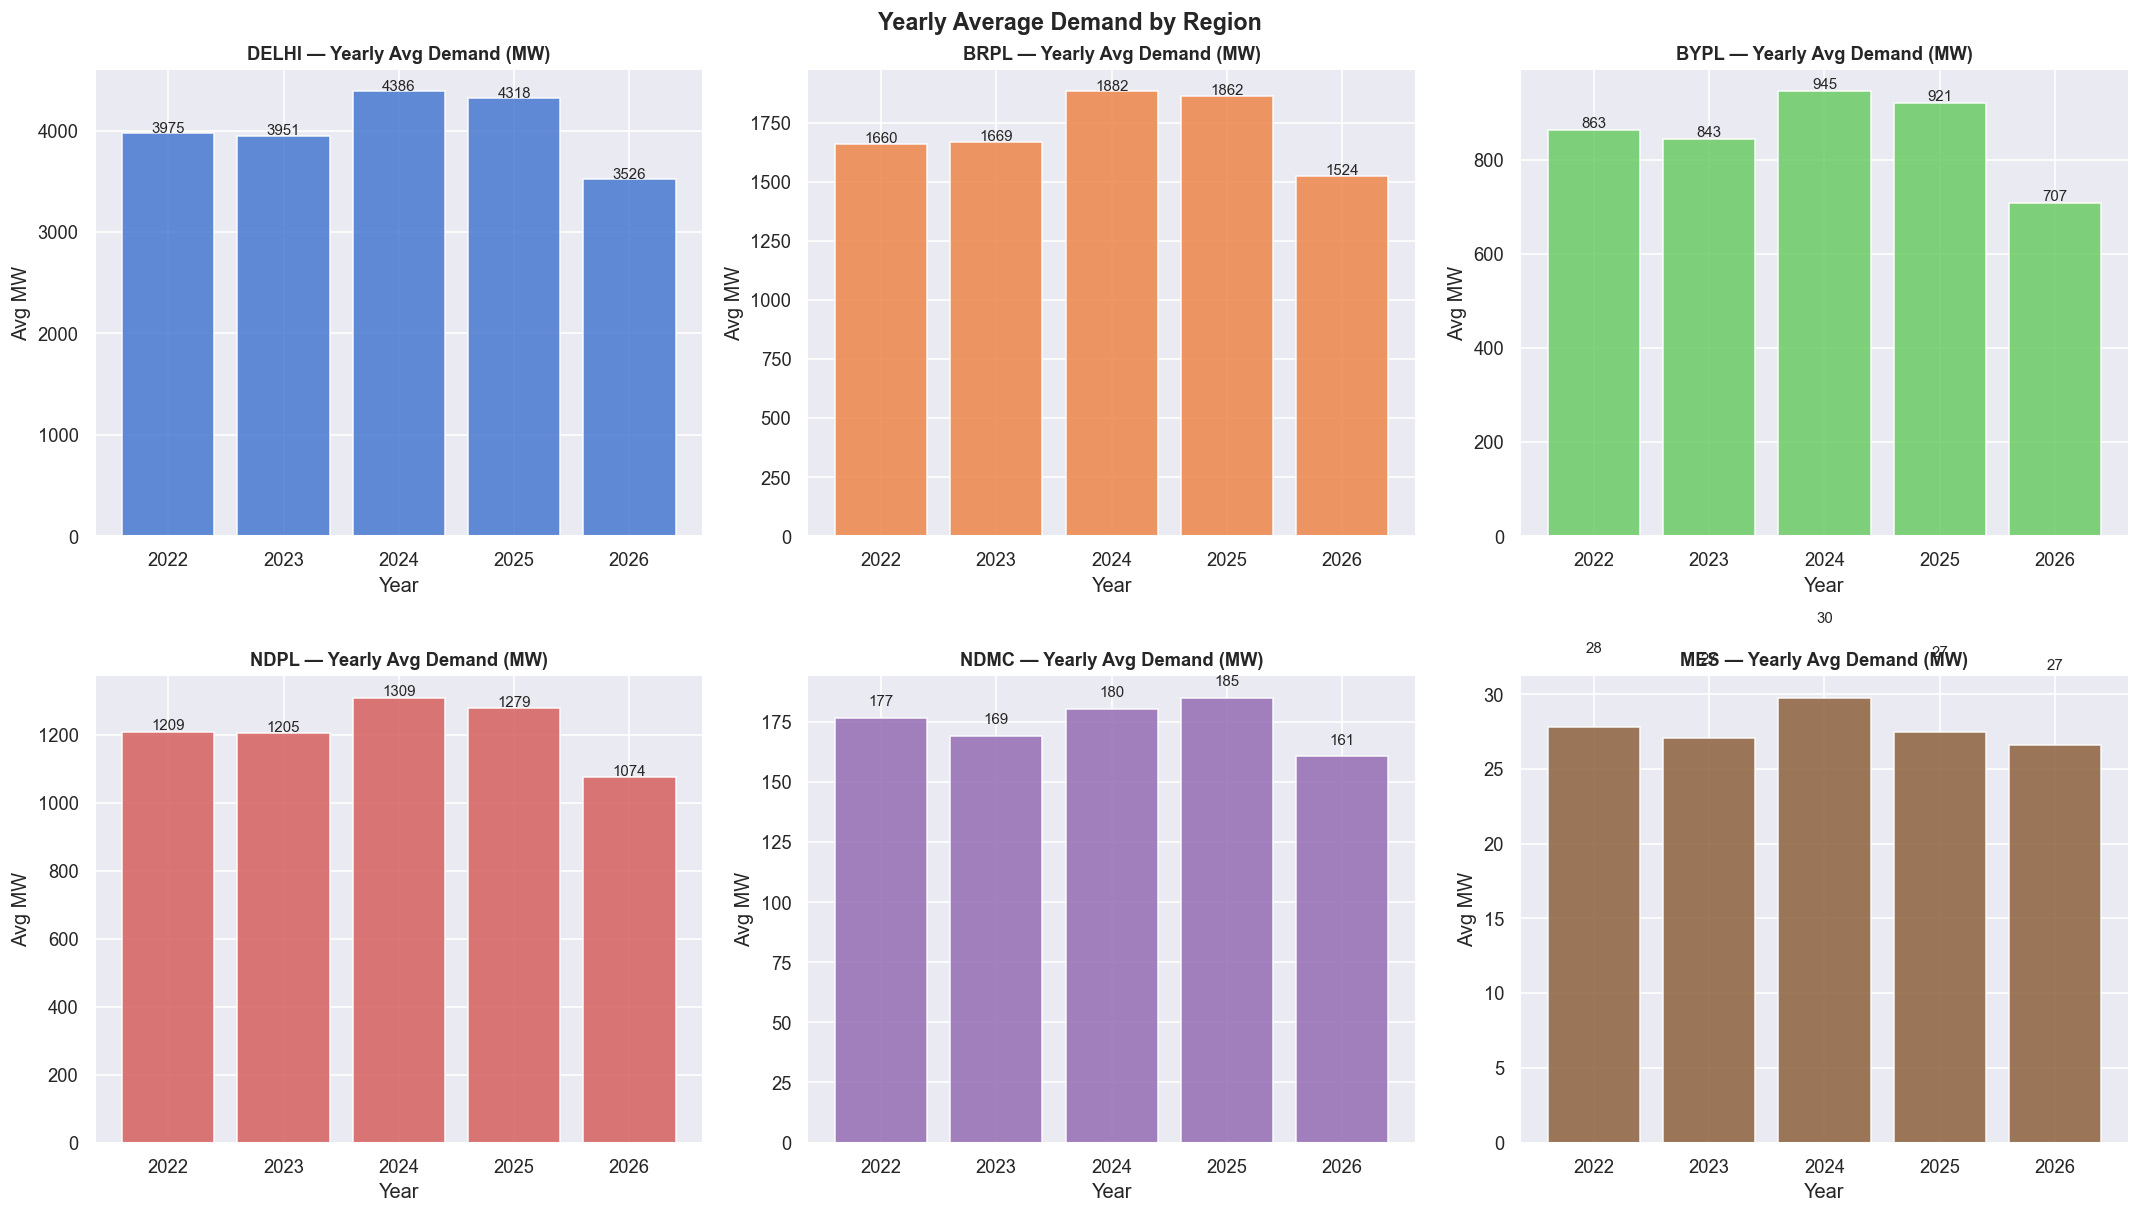

Key insight: 2024 saw highest demand — likely due to extreme heat wave


In [9]:
# ── Extract time-based features from datetime column ──
sldc['year']  = sldc['datetime'].dt.year         # Year (2022, 2023, ...)
sldc['month'] = sldc['datetime'].dt.month        # Month number (1 to 12)
sldc['hour']  = sldc['datetime'].dt.hour         # Hour of day (0 to 23)
sldc['dow']   = sldc['datetime'].dt.dayofweek    # Day of week (0=Monday)

# ── Create subplot layout: 2 rows × 3 columns ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Convert subplot matrix into 1D array for easy looping
axes = axes.flatten()

# ── Plot yearly average demand for each region ──
for i, r in enumerate(REGIONS):

    # Calculate average yearly demand for current region
    yearly = sldc.groupby('year')[r].mean()

    # Create bar chart
    axes[i].bar(
        yearly.index,                 # X-axis = Years
        yearly.values,               # Y-axis = Avg demand
        color=sns.color_palette('muted')[i],
        alpha=0.85
    )

    # Add chart title
    axes[i].set_title(
        f'{r} — Yearly Avg Demand (MW)',
        fontsize=11,
        fontweight='bold'
    )

    # Axis labels
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Avg MW')

    # Add values above each bar
    for x, y in zip(yearly.index, yearly.values):
        axes[i].text(
            x, y + 5,
            f'{y:.0f}',
            ha='center',
            fontsize=9
        )

# Adjust subplot spacing automatically
plt.tight_layout()

# Main figure title
plt.suptitle(
    'Yearly Average Demand by Region',
    y=1.01,
    fontsize=14,
    fontweight='bold'
)

# Save chart image
plt.savefig('01_yearly_demand.png', bbox_inches='tight')

# Display chart
plt.show()

# Print business insight
print('Key insight: 2024 saw highest demand — likely due to extreme heat wave')

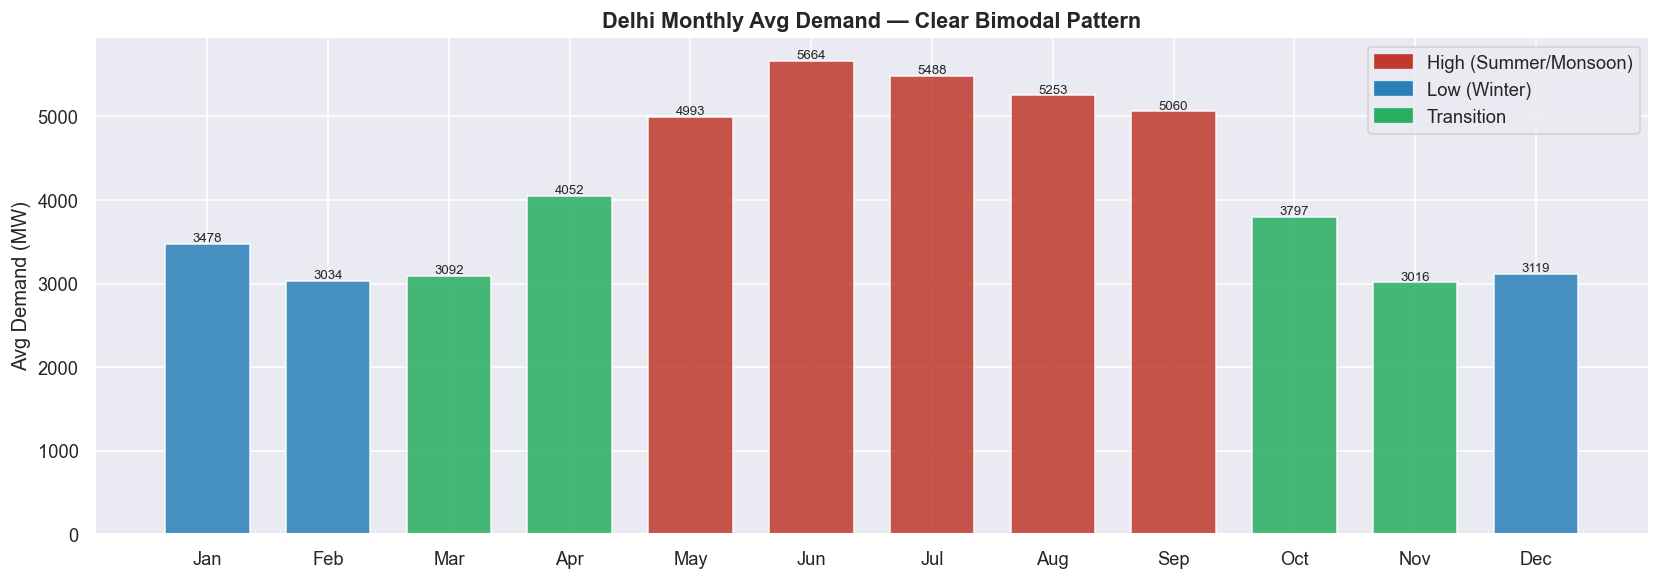

Peak months: Jun-Sep (AC + industrial load)
Trough months: Feb-Mar, Nov


In [11]:
# ── Month labels for x-axis ──
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Calculate average monthly demand for Delhi region
monthly = sldc.groupby('month')['DELHI'].mean()

# ── Create figure ──
fig, ax = plt.subplots(figsize=(14, 5))

# Assign colors based on season type
colors = [
    '#c0392b' if m in [5, 6, 7, 8, 9] else      # Summer / Monsoon = High demand
    '#2980b9' if m in [1, 2, 12] else           # Winter = Low demand
    '#27ae60'                                   # Transition months
    for m in range(1, 13)
]

# Plot bar chart
bars = ax.bar(
    range(1, 13),              # Months 1 to 12
    monthly.values,            # Average demand values
    color=colors,
    alpha=0.85,
    width=0.7
)

# Set x-axis ticks and labels
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)

# Axis labels and title
ax.set_ylabel('Avg Demand (MW)')
ax.set_title(
    'Delhi Monthly Avg Demand — Clear Bimodal Pattern',
    fontsize=13,
    fontweight='bold'
)

# ── Custom legend ──
from matplotlib.patches import Patch

legend = [
    Patch(color='#c0392b', label='High (Summer/Monsoon)'),
    Patch(color='#2980b9', label='Low (Winter)'),
    Patch(color='#27ae60', label='Transition')
]

ax.legend(handles=legend)

# Add value labels above bars
for bar, v in zip(bars, monthly.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 30,
        f'{v:.0f}',
        ha='center',
        fontsize=8
    )

# Adjust spacing
plt.tight_layout()

# Save chart image
plt.savefig('02_monthly_seasonality.png', bbox_inches='tight')

# Display chart
plt.show()

# Print insights
print('Peak months: Jun-Sep (AC + industrial load)')
print('Trough months: Feb-Mar, Nov')

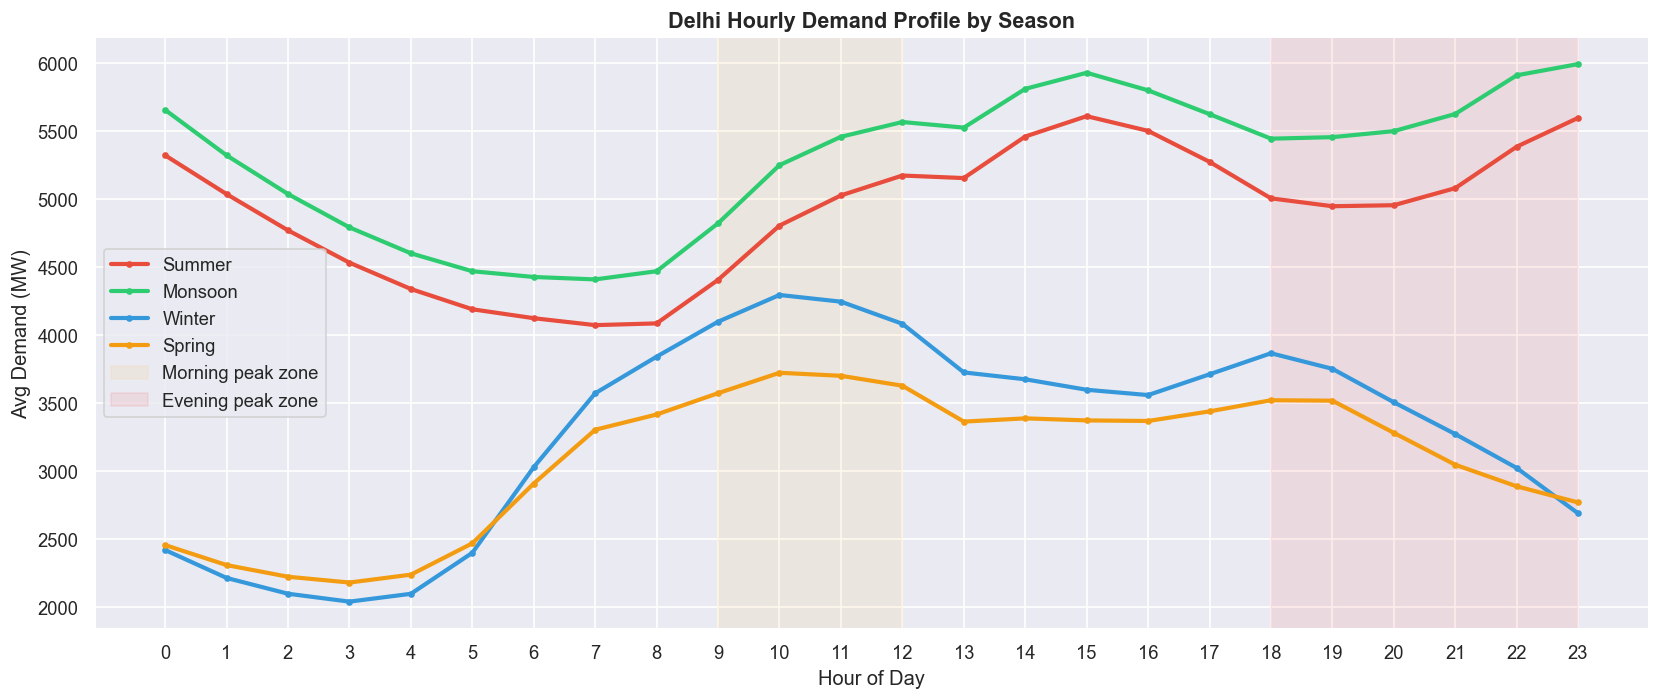

Season-wise peak hours:
  Summer: Morning peak=12h, Evening peak=22h
  Monsoon: Morning peak=12h, Evening peak=22h
  Winter: Morning peak=10h, Evening peak=18h


In [13]:
# ── Function to classify month into season ──
def get_season(m):

    # Summer months
    if m in [4, 5, 6]:
        return 'Summer'

    # Monsoon months
    elif m in [7, 8, 9]:
        return 'Monsoon'

    # Winter months
    elif m in [10, 11, 12, 1, 2]:
        return 'Winter'

    # Remaining months
    else:
        return 'Spring'


# Create new season column using month values
sldc['season'] = sldc['month'].apply(get_season)

# ── Create plot ──
fig, ax = plt.subplots(figsize=(14, 6))

# Define color palette for seasons
palette = {
    'Summer':  '#e74c3c',
    'Monsoon': '#2ecc71',
    'Winter':  '#3498db',
    'Spring':  '#f39c12'
}

# Plot hourly average demand curve for each season
for s, color in palette.items():

    # Average Delhi demand by hour for selected season
    sub = sldc[sldc['season'] == s].groupby('hour')['DELHI'].mean()

    # Line plot
    ax.plot(
        sub.index,              # Hours (0 to 23)
        sub.values,             # Avg demand
        label=s,
        color=color,
        linewidth=2.5,
        marker='o',
        markersize=3
    )

# Axis labels
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Demand (MW)')

# Chart title
ax.set_title(
    'Delhi Hourly Demand Profile by Season',
    fontsize=13,
    fontweight='bold'
)

# Show all 24 hour ticks
ax.set_xticks(range(24))

# Highlight morning peak hours
ax.axvspan(
    9, 12,
    alpha=0.07,
    color='orange',
    label='Morning peak zone'
)

# Highlight evening peak hours
ax.axvspan(
    18, 23,
    alpha=0.07,
    color='red',
    label='Evening peak zone'
)

# Show legend
ax.legend()

# Adjust spacing
plt.tight_layout()

# Save chart image
plt.savefig('03_hourly_profile.png', bbox_inches='tight')

# Display chart
plt.show()

# ── Print season-wise peak hour insights ──
print('Season-wise peak hours:')

for s in ['Summer', 'Monsoon', 'Winter']:

    # Compute hourly average demand
    sub = sldc[sldc['season'] == s].groupby('hour')['DELHI'].mean()

    # Print peak hours
    print(
        f"  {s}: "
        f"Morning peak={sub[9:13].idxmax()}h, "
        f"Evening peak={sub[17:23].idxmax()}h"
    )

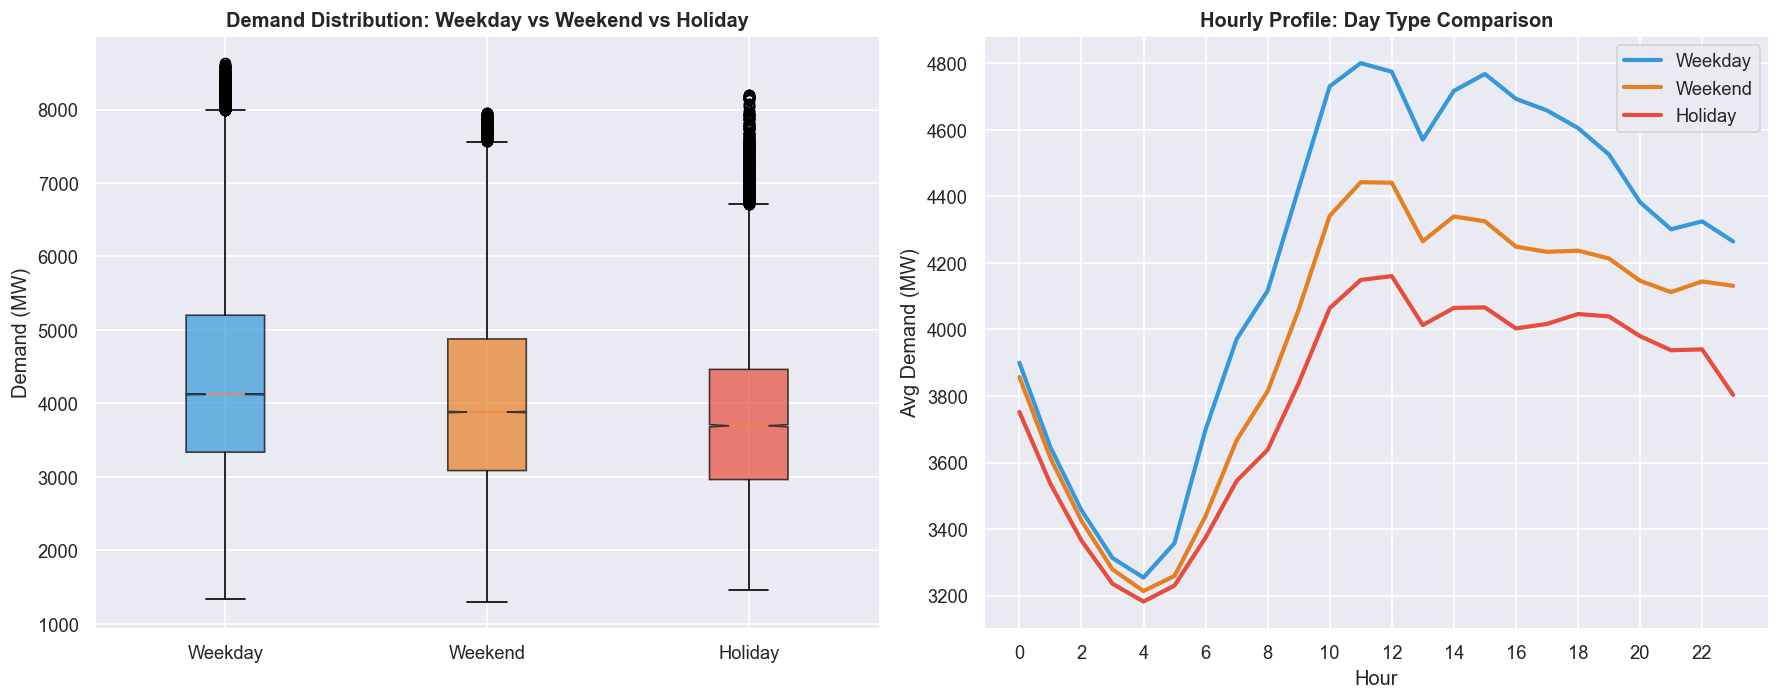

Weekday   : 4214.0 MW avg
Weekend   : 3964.4 MW avg
Holiday   : 3789.6 MW avg

📉 Holiday reduces demand by 10.1% vs Weekday


In [15]:
# ── Create date string column for holiday matching ──
sldc['date_str'] = sldc['datetime'].dt.strftime('%Y-%m-%d')

# Mark public holidays (1 = Holiday, 0 = Normal day)
sldc['is_holiday'] = sldc['date_str'].isin(HOLIDAY_SET).astype(int)

# Mark weekends (Saturday=5, Sunday=6)
sldc['is_weekend'] = (sldc['dow'] >= 5).astype(int)


# ── Function to classify day type ──
def day_type(row):

    # Highest priority = Holiday
    if row['is_holiday']:
        return 'Holiday'

    # Weekend but not holiday
    elif row['is_weekend']:
        return 'Weekend'

    # Regular working day
    else:
        return 'Weekday'


# Apply function row-wise
sldc['day_type'] = sldc.apply(day_type, axis=1)

# ── Create figure with 2 subplots ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ==================================================
# LEFT PLOT → BOXPLOT OF DEMAND DISTRIBUTION
# ==================================================

# Order of categories
order = ['Weekday', 'Weekend', 'Holiday']

# Colors for each category
colors_box = {
    'Weekday': '#3498db',
    'Weekend': '#e67e22',
    'Holiday': '#e74c3c'
}

# Prepare data for boxplot
bp_data = [
    sldc[sldc['day_type'] == d]['DELHI'].values
    for d in order
]

# Draw boxplot
bp = axes[0].boxplot(
    bp_data,
    labels=order,
    patch_artist=True,
    notch=True
)

# Apply colors
for patch, d in zip(bp['boxes'], order):
    patch.set_facecolor(colors_box[d])
    patch.set_alpha(0.7)

# Labels
axes[0].set_ylabel('Demand (MW)')
axes[0].set_title(
    'Demand Distribution: Weekday vs Weekend vs Holiday',
    fontweight='bold'
)

# ==================================================
# RIGHT PLOT → HOURLY DEMAND PROFILE
# ==================================================

for dt in order:

    # Avg hourly demand by day type
    sub = sldc[sldc['day_type'] == dt].groupby('hour')['DELHI'].mean()

    # Plot line chart
    axes[1].plot(
        sub.index,
        sub.values,
        label=dt,
        color=colors_box[dt],
        linewidth=2.5
    )

# Labels
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg Demand (MW)')
axes[1].set_title(
    'Hourly Profile: Day Type Comparison',
    fontweight='bold'
)

# Legend + x-axis ticks
axes[1].legend()
axes[1].set_xticks(range(0, 24, 2))

# Adjust spacing
plt.tight_layout()

# Save figure
plt.savefig('04_holiday_impact.png', bbox_inches='tight')

# Show chart
plt.show()

# ── Print average demand by day type ──
for dt in order:
    avg = sldc[sldc['day_type'] == dt]['DELHI'].mean()
    print(f'{dt:10s}: {avg:.1f} MW avg')

# Compare holiday vs weekday demand
wkd = sldc[sldc['day_type'] == 'Weekday']['DELHI'].mean()
hol = sldc[sldc['day_type'] == 'Holiday']['DELHI'].mean()

print(
    f'\n📉 Holiday reduces demand by '
    f'{(1 - hol / wkd) * 100:.1f}% vs Weekday'
)

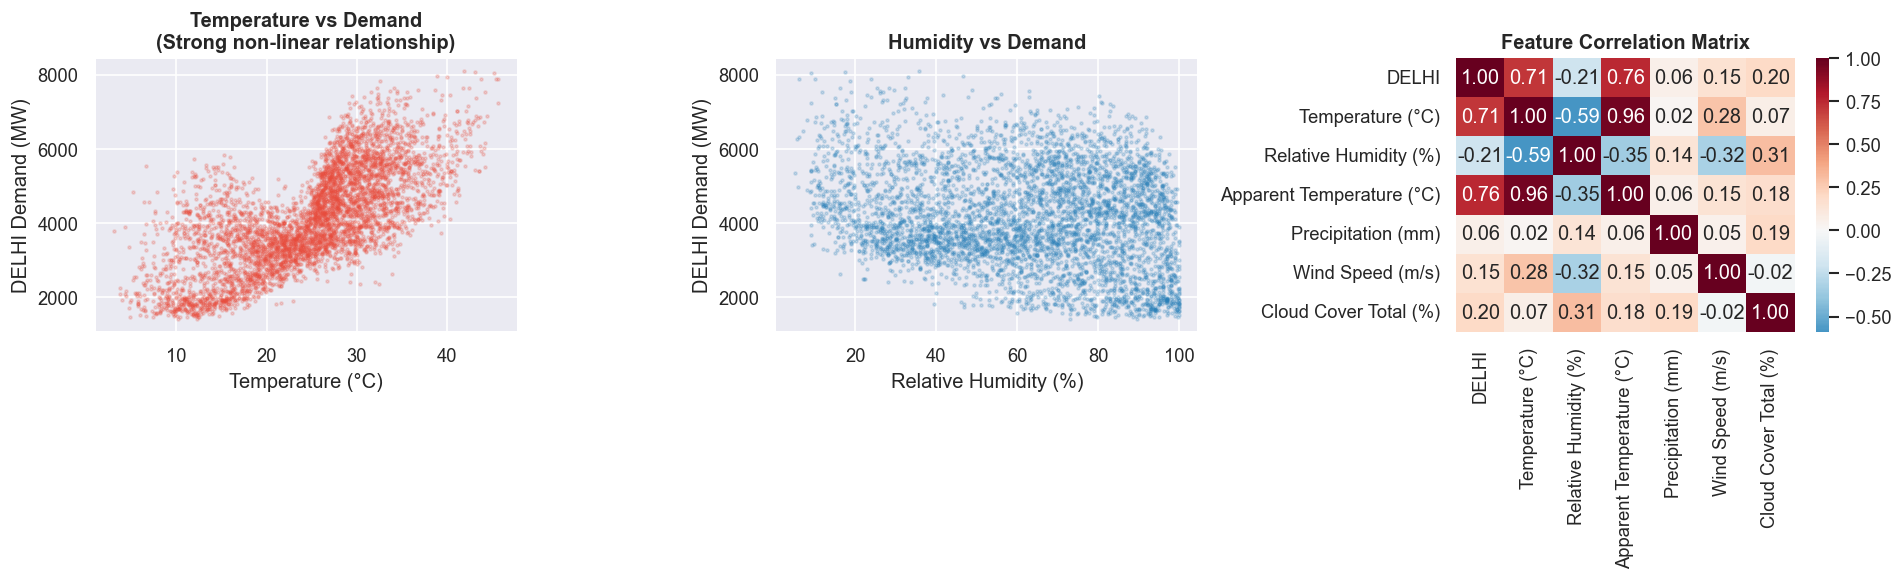

Correlation with DELHI demand:
Apparent Temperature (°C)    0.756262
Temperature (°C)             0.710027
Cloud Cover Total (%)        0.197317
Wind Speed (m/s)             0.150930
Precipitation (mm)           0.060964
Relative Humidity (%)       -0.208817
Name: DELHI, dtype: float64


In [16]:
# ── Select useful weather columns for merge ──
wx_tmp = wx[
    [
        'datetime',
        'Temperature (°C)',
        'Relative Humidity (%)',
        'Apparent Temperature (°C)',
        'Precipitation (mm)',
        'Wind Speed (m/s)',
        'Cloud Cover Total (%)'
    ]
].copy()

# ── Merge electricity demand + weather data on datetime ──
merged_tmp = pd.merge(
    sldc[['datetime', 'DELHI']],
    wx_tmp,
    on='datetime',
    how='inner'
)

# ── Create figure with 3 subplots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ==================================================
# PLOT 1 → TEMPERATURE VS DEMAND
# ==================================================

# Random sample for faster plotting
sample = merged_tmp.sample(5000, random_state=42)

axes[0].scatter(
    sample['Temperature (°C)'],
    sample['DELHI'],
    alpha=0.2,
    s=3,
    c='#e74c3c'
)

axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('DELHI Demand (MW)')
axes[0].set_title(
    'Temperature vs Demand\n(Strong non-linear relationship)',
    fontweight='bold'
)

# ==================================================
# PLOT 2 → HUMIDITY VS DEMAND
# ==================================================

axes[1].scatter(
    sample['Relative Humidity (%)'],
    sample['DELHI'],
    alpha=0.2,
    s=3,
    c='#2980b9'
)

axes[1].set_xlabel('Relative Humidity (%)')
axes[1].set_ylabel('DELHI Demand (MW)')
axes[1].set_title(
    'Humidity vs Demand',
    fontweight='bold'
)

# ==================================================
# PLOT 3 → CORRELATION HEATMAP
# ==================================================

# Compute correlation matrix
corr = merged_tmp[
    [
        'DELHI',
        'Temperature (°C)',
        'Relative Humidity (%)',
        'Apparent Temperature (°C)',
        'Precipitation (mm)',
        'Wind Speed (m/s)',
        'Cloud Cover Total (%)'
    ]
].corr()

# Heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=axes[2],
    cbar=True
)

axes[2].set_title(
    'Feature Correlation Matrix',
    fontweight='bold'
)

# ── Final formatting ──
plt.tight_layout()

# Save figure
plt.savefig('05_weather_correlation.png', bbox_inches='tight')

# Display chart
plt.show()

# ── Print correlation with Delhi demand ──
print('Correlation with DELHI demand:')

print(
    corr['DELHI']
    .drop('DELHI')
    .sort_values(ascending=False)
)

In [19]:
# ── Outlier detection using percentile method ──
print('=== Outlier Analysis (1st–99th percentile method) ===')

# Dictionary to store lower and upper bounds for each region
OUTLIER_BOUNDS = {}

# Loop through each electricity region
for r in REGIONS:

    # Lower bound = 0.5th percentile
    q_low = sldc[r].quantile(0.005)

    # Upper bound = 99.5th percentile
    q_high = sldc[r].quantile(0.995)

    # Count records outside bounds
    n_out = (
        (sldc[r] < q_low) |
        (sldc[r] > q_high)
    ).sum()

    # Store bounds
    OUTLIER_BOUNDS[r] = (q_low, q_high)

    # Percentage of outliers
    pct = n_out / len(sldc) * 100

    # Print region-wise summary
    print(
        f'{r:6s}: '
        f'[{q_low:.1f} – {q_high:.1f}] MW | '
        f'Outliers: {n_out} ({pct:.2f}%)'
    )

# ── Special anomaly check for BRPL ──
# Known extreme spike in data
print(
    f'\n⚠️  BRPL spike check: '
    f'max={sldc["BRPL"].max():.1f} MW on',
    sldc.loc[sldc['BRPL'].idxmax(), 'datetime']
)

=== Outlier Analysis (1st–99th percentile method) ===
DELHI : [1568.6 – 7443.9] MW | Outliers: 4308 (1.00%)
BRPL  : [636.7 – 3308.6] MW | Outliers: 4307 (1.00%)
BYPL  : [273.4 – 1639.2] MW | Outliers: 4308 (1.00%)
NDPL  : [492.4 – 2132.5] MW | Outliers: 4306 (1.00%)
NDMC  : [78.0 – 367.2] MW | Outliers: 4305 (1.00%)
MES   : [12.6 – 51.5] MW | Outliers: 4277 (0.99%)

⚠️  BRPL spike check: max=64333.2 MW on 2023-12-28 17:30:00


In [21]:
# =====================================================
# 5.1 MERGE ELECTRICITY + WEATHER DATA
# =====================================================

# Select useful weather columns only
wx_feats = wx[
    [
        'datetime',
        'Temperature (°C)',
        'Relative Humidity (%)',
        'Apparent Temperature (°C)',
        'Precipitation (mm)',
        'Wind Speed (m/s)',
        'Cloud Cover Total (%)'
    ]
].copy()

# Rename long column name for convenience
wx_feats.rename(
    columns={
        'Apparent Temperature (°C)': 'feels_like'
    },
    inplace=True
)

# Merge demand data + weather data using datetime
df = pd.merge(
    sldc,
    wx_feats,
    on='datetime',
    how='inner'
)

# Print merged dataset size
print(f'Merged shape: {df.shape}')


# =====================================================
# 5.2 REMOVE OUTLIERS (WINSORIZATION)
# =====================================================

print('\nRemoving outliers...')

# Store row count before cleaning
before = len(df)

# Clip extreme values region-wise using 0.5% to 99.5% bounds
for r in REGIONS:

    lo = df[r].quantile(0.005)
    hi = df[r].quantile(0.995)

    df[r] = df[r].clip(lo, hi)

# Remove known BRPL spike anomaly manually
df = df[df['BRPL'] < 10000].copy()

# Row count after cleaning
after = len(df)

print(f'Outliers handled: {before - after} rows removed/clipped')


# =====================================================
# 5.3 BASIC TIME FEATURES
# =====================================================

df['hour']         = df['datetime'].dt.hour
df['day_of_week']  = df['datetime'].dt.dayofweek
df['month']        = df['datetime'].dt.month
df['year']         = df['datetime'].dt.year
df['day_of_year']  = df['datetime'].dt.dayofyear
df['week_of_year'] = df['datetime'].dt.isocalendar().week.astype(int)

# Date string for holiday matching
df['date_str'] = df['datetime'].dt.strftime('%Y-%m-%d')

# Season label using custom function
df['season'] = df['month'].apply(get_season)


# =====================================================
# 5.4 CYCLIC FEATURES
# =====================================================
# Used because hour/month/day are circular values

# Hour cycle
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Month cycle
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Day of week cycle
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)


# =====================================================
# 5.5 FLAG / BINARY FEATURES
# =====================================================

# Weekend flag
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Holiday flag
df['is_holiday'] = df['date_str'].isin(HOLIDAY_SET).astype(int)

# Seasonal flags
df['is_monsoon'] = df['month'].isin([7, 8, 9]).astype(int)
df['is_summer']  = df['month'].isin([4, 5, 6]).astype(int)
df['is_winter']  = df['month'].isin([10, 11, 12, 1, 2]).astype(int)


# =====================================================
# 5.6 SEASON-AWARE PEAK LOAD FLAGS
# =====================================================
# Derived from EDA patterns


def is_morning_peak(row):

    h = row['hour']
    s = row['season']

    if s == 'Winter':
        return int(9 <= h <= 11)

    elif s in ['Summer', 'Monsoon']:
        return int(11 <= h <= 13)

    else:   # Spring
        return int(10 <= h <= 12)


def is_evening_peak(row):

    h = row['hour']
    s = row['season']

    if s == 'Winter':
        return int(17 <= h <= 19)

    elif s in ['Summer', 'Monsoon']:
        return int(20 <= h <= 23)

    else:   # Spring
        return int(18 <= h <= 21)


# Apply custom peak functions
df['is_morning_peak'] = df.apply(is_morning_peak, axis=1)
df['is_evening_peak'] = df.apply(is_evening_peak, axis=1)


# =====================================================
# 5.7 YEAR TREND FEATURE
# =====================================================
# Normalize year between 0 and 1

df['year_norm'] = (df['year'] - 2022) / 5


# =====================================================
# FINAL OUTPUT
# =====================================================

print('\n✅ Feature engineering complete')
print(f'Dataset shape: {df.shape}')

Merged shape: (430771, 24)

Removing outliers...
Outliers handled: 0 rows removed/clipped

✅ Feature engineering complete
Dataset shape: (430771, 39)


In [23]:
# =====================================================
# CONVERT 5-MINUTE DATA TO HOURLY DATA
# =====================================================
# Final prediction system requires hourly inputs
# (same frequency as Open-Meteo API forecast data)

# Create hourly timestamp by flooring datetime
# Example: 10:25 → 10:00
df['hour_dt'] = df['datetime'].dt.floor('h')


# =====================================================
# DEFINE AGGREGATION RULES
# =====================================================

# Region demand columns → hourly average demand
agg_dict = {r: 'mean' for r in REGIONS}

# Add aggregation rules for weather + engineered features
agg_dict.update({

    # Weather features
    'Temperature (°C)': 'mean',
    'Relative Humidity (%)': 'mean',
    'feels_like': 'mean',
    'Precipitation (mm)': 'sum',          # total rainfall in hour
    'Wind Speed (m/s)': 'mean',
    'Cloud Cover Total (%)': 'mean',

    # Time features
    'hour': 'first',
    'day_of_week': 'first',
    'month': 'first',
    'year': 'first',
    'day_of_year': 'first',
    'week_of_year': 'first',
    'year_norm': 'first',

    # Cyclic features
    'hour_sin': 'first',
    'hour_cos': 'first',
    'month_sin': 'first',
    'month_cos': 'first',
    'dow_sin': 'first',
    'dow_cos': 'first',

    # Flags
    'is_weekend': 'first',
    'is_holiday': 'first',
    'is_monsoon': 'first',
    'is_summer': 'first',
    'is_winter': 'first',
    'is_morning_peak': 'first',
    'is_evening_peak': 'first',

    # Labels / helper columns
    'season': 'first',
    'date_str': 'first'
})


# =====================================================
# AGGREGATE TO HOURLY LEVEL
# =====================================================

df_hourly = (
    df.groupby('hour_dt')
      .agg(agg_dict)
      .reset_index()
)

# Rename timestamp column back to datetime
df_hourly.rename(
    columns={'hour_dt': 'datetime'},
    inplace=True
)


# =====================================================
# PRINT SUMMARY
# =====================================================

print(f'Hourly dataset: {df_hourly.shape}')

print(
    f'Date range: '
    f'{df_hourly["datetime"].min()} → '
    f'{df_hourly["datetime"].max()}'
)

print(
    f'Expected rows (4 years + ~4 months): '
    f'~{int(df_hourly.shape[0])} hours'
)

Hourly dataset: (36193, 35)
Date range: 2022-01-01 00:00:00 → 2026-04-01 23:00:00
Expected rows (4 years + ~4 months): ~36193 hours


In [25]:
FEATURES = [
    # Time - Raw
    'hour', 'day_of_week', 'month', 'year', 'day_of_year', 'week_of_year', 'year_norm',
    # Time - Cyclic
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    # Season-aware peaks
    'is_morning_peak', 'is_evening_peak',
    # Flags
    'is_weekend', 'is_holiday', 'is_monsoon', 'is_summer', 'is_winter',
    # Weather
    'Temperature (°C)', 'Relative Humidity (%)', 'feels_like',
    'Precipitation (mm)', 'Wind Speed (m/s)', 'Cloud Cover Total (%)'
]

print(f'✅ Total features: {len(FEATURES)}')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')

# Verify all features exist
missing = [f for f in FEATURES if f not in df_hourly.columns]
if missing:
    print(f'\n❌ Missing features: {missing}')
else:
    print('\n✅ All features present in dataset')

✅ Total features: 26
   1. hour
   2. day_of_week
   3. month
   4. year
   5. day_of_year
   6. week_of_year
   7. year_norm
   8. hour_sin
   9. hour_cos
  10. month_sin
  11. month_cos
  12. dow_sin
  13. dow_cos
  14. is_morning_peak
  15. is_evening_peak
  16. is_weekend
  17. is_holiday
  18. is_monsoon
  19. is_summer
  20. is_winter
  21. Temperature (°C)
  22. Relative Humidity (%)
  23. feels_like
  24. Precipitation (mm)
  25. Wind Speed (m/s)
  26. Cloud Cover Total (%)

✅ All features present in dataset


In [27]:
# Train on full dataset

train_df = df_hourly.copy()
test_df = None

print(
    f'Training size: {len(train_df):,} hourly records '
    f'({train_df["datetime"].min().date()} → '
    f'{train_df["datetime"].max().date()})'
)

X_train = train_df[FEATURES]

print('\n✅ Full dataset ready for training')

Training size: 36,193 hourly records (2022-01-01 → 2026-04-01)

✅ Full dataset ready for training


In [29]:
# ── Helper: Metrics ──
def compute_metrics(y_true, y_pred, region=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    acc  = 100 - mape
    return {'region': region, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'Accuracy': acc}


all_models  = {}
all_weights = {}

# Validation = last 3 months
val_cutoff  = train_df['datetime'].max() - pd.DateOffset(months=3)
train_inner = train_df[train_df['datetime'] <= val_cutoff].copy()
val_df      = train_df[train_df['datetime'] > val_cutoff].copy()

X_train_inner = train_inner[FEATURES]
X_val         = val_df[FEATURES]
X_train_full  = train_df[FEATURES]

print(f'Inner train: {len(train_inner):,}')
print(f'Validation : {len(val_df):,}')
print('=' * 60)

for region in REGIONS:

    print(f'\n🔄 Training for {region}')

    y_train_inner = train_inner[region]
    y_val         = val_df[region]
    y_train_full  = train_df[region]

    # ── XGBoost ──
    xgb_model = xgb.XGBRegressor(
        n_estimators=1200,
        learning_rate=0.04,
        max_depth=7,
        subsample=0.80,
        colsample_bytree=0.80,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
        early_stopping_rounds=50,
        eval_metric='mae'
    )

    xgb_model.fit(
        X_train_inner, y_train_inner,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    xgb_mae = mean_absolute_error(y_val, xgb_model.predict(X_val))


    # ── LightGBM ──
    lgb_model = lgb.LGBMRegressor(
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.80,
        colsample_bytree=0.80,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )

    lgb_model.fit(
        X_train_inner, y_train_inner,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    lgb_mae = mean_absolute_error(y_val, lgb_model.predict(X_val))


    # ── CatBoost ──
    cat_model = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.04,
        depth=7,
        random_seed=RANDOM_STATE,
        verbose=0
    )

    cat_model.fit(
        X_train_inner, y_train_inner,
        eval_set=(X_val, y_val)
    )

    cat_mae = mean_absolute_error(y_val, cat_model.predict(X_val))


    # ── Ensemble Weights ──
    inv = np.array([1/xgb_mae, 1/lgb_mae, 1/cat_mae])
    weights = inv / inv.sum()

    all_weights[region] = {
        'xgb': weights[0],
        'lgb': weights[1],
        'cat': weights[2]
    }

    print(f'Weights → XGB:{weights[0]:.3f} | LGB:{weights[1]:.3f} | CAT:{weights[2]:.3f}')


    # ── Final Retrain on Full Dataset ──
    xgb_final = xgb.XGBRegressor(
        n_estimators=xgb_model.best_iteration + 50,
        learning_rate=0.04,
        max_depth=7,
        subsample=0.80,
        colsample_bytree=0.80,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist'
    )
    xgb_final.fit(X_train_full, y_train_full)


    lgb_final = lgb.LGBMRegressor(
        n_estimators=lgb_model.best_iteration_ + 50,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.80,
        colsample_bytree=0.80,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
    lgb_final.fit(X_train_full, y_train_full)


    cat_final = CatBoostRegressor(
        iterations=cat_model.best_iteration_ + 50,
        learning_rate=0.04,
        depth=7,
        random_seed=RANDOM_STATE,
        verbose=0
    )
    cat_final.fit(X_train_full, y_train_full)


    all_models[region] = {
        'xgb': xgb_final,
        'lgb': lgb_final,
        'cat': cat_final
    }

    print('✅ Final models trained on full dataset')


print('\n' + '=' * 60)
print('✅ All regions final training complete')

Inner train: 34,075
Validation : 2,118

🔄 Training for DELHI
Weights → XGB:0.353 | LGB:0.341 | CAT:0.306
✅ Final models trained on full dataset

🔄 Training for BRPL
Weights → XGB:0.364 | LGB:0.344 | CAT:0.292
✅ Final models trained on full dataset

🔄 Training for BYPL
Weights → XGB:0.338 | LGB:0.327 | CAT:0.334
✅ Final models trained on full dataset

🔄 Training for NDPL
Weights → XGB:0.346 | LGB:0.333 | CAT:0.321
✅ Final models trained on full dataset

🔄 Training for NDMC
Weights → XGB:0.342 | LGB:0.339 | CAT:0.319
✅ Final models trained on full dataset

🔄 Training for MES
Weights → XGB:0.336 | LGB:0.334 | CAT:0.329
✅ Final models trained on full dataset

✅ All regions final training complete


In [31]:
import joblib
import os

os.makedirs("models_full", exist_ok=True)

for region in all_models:
    joblib.dump(all_models[region]['xgb'], f"models_full/{region}_xgb.pkl")
    joblib.dump(all_models[region]['lgb'], f"models_full/{region}_lgb.pkl")
    joblib.dump(all_models[region]['cat'], f"models_full/{region}_cat.pkl")

joblib.dump(all_weights, "models_full/ensemble_weights.pkl")

print("✅ Models saved successfully")

✅ Models saved successfully
